In [1]:
# Setup
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: []


In [2]:
# Load the MNIST dataset
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

print("Train shape:", x_train.shape)
print("Test shape :", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Train shape: (60000, 28, 28)
Test shape : (10000, 28, 28)


Train shape after reshape: (60000, 28, 28, 1)


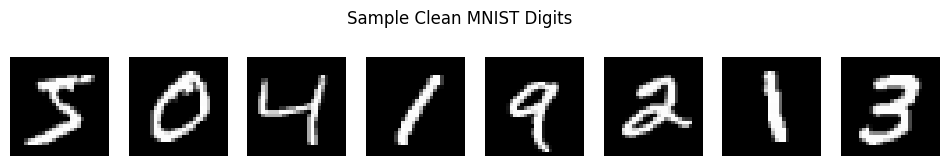

In [3]:
# Preprocess

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1)) ## adding channel beacuse convex2d() layer expects (height,width,channel)
## sample check with quick plot we make sure here that the preprocessing deosnt affected the digits
print("Train shape after reshape:", x_train.shape)
n = 8
plt.figure(figsize=(12, 2))
for i in range(n):
    ax = plt.subplot(1, n, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap='gray')
    plt.axis('off')
plt.suptitle("Sample Clean MNIST Digits")
plt.show()

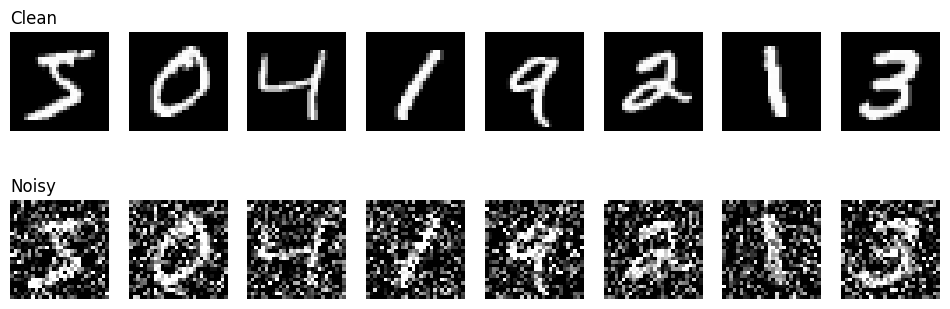

In [4]:
# Add Artificial noise

noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0, scale=1.0, size=x_train.shape
)
x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0, scale=1.0, size=x_test.shape
)

x_train_noisy = np.clip(x_train_noisy, 0.0, 1.0)
x_test_noisy = np.clip(x_test_noisy, 0.0, 1.0)

n = 8
plt.figure(figsize=(12, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap='gray')
    plt.axis('off')
    if i == 0: ax.set_title("Clean", loc='left')

    ax = plt.subplot(2, n, n + i + 1)
    plt.imshow(x_train_noisy[i].squeeze(), cmap='gray')
    plt.axis('off')
    if i == 0: ax.set_title("Noisy", loc='left')
plt.show()

In [5]:
# Build an Autoencoder (encoder+decoder)

def build_denoising_autoencoder():
    input_img = layers.Input(shape=(28, 28, 1))

    # ---- Encoder: compress the image ----
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)          # 14x14x32
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    encoded = layers.MaxPooling2D((2, 2), padding='same')(x)    # 7x7x32 (bottleneck)

    # ---- Decoder: rebuild the image ----
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(encoded)
    x = layers.UpSampling2D((2, 2))(x)                          # 14x14x32
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)                          # 28x28x32
    decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

    return models.Model(input_img, decoded, name="denoising_autoencoder")

autoencoder = build_denoising_autoencoder()
autoencoder.summary()

Model: "denoising_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Compile and train

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

early_stop = callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

history = autoencoder.fit(
    x_train_noisy, x_train,        # input = noisy, target = clean
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test),
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 173ms/step - loss: 0.1629 - val_loss: 0.1171
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 77s 161ms/step - loss: 0.1136 - val_loss: 0.1085
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 164ms/step - loss: 0.1077 - val_loss: 0.1049
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 163ms/step - loss: 0.1047 - val_loss: 0.1025
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 79s 168ms/step - loss: 0.1029 - val_loss: 0.1011
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 166ms/step - loss: 0.1014 - val_loss: 0.0997
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 163ms/step - loss: 0.1001 - val_loss: 0.0986
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 75s 160ms/step - loss: 0.0992 - val_loss: 0.0979
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 76s 161ms/step - loss: 0.0985 - val_loss: 0.0974
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 80s 156ms/step - loss: 0.0980 - val_loss: 0.0969


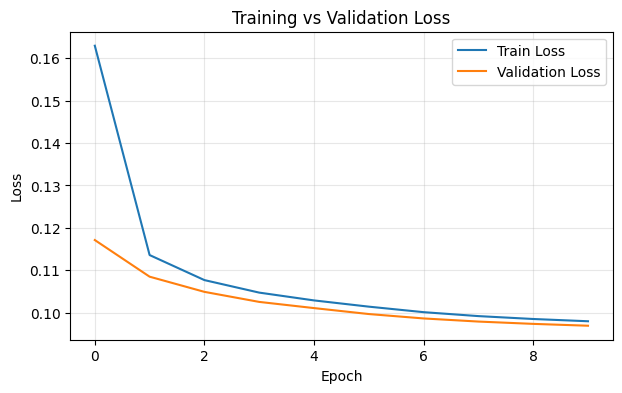

In [7]:
# Graph

plt.figure(figsize=(7, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

In [8]:
# generate denoised outputs
denoised_images = autoencoder.predict(x_test_noisy)
print("Denoised output shape:", denoised_images.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step
Denoised output shape: (10000, 28, 28, 1)


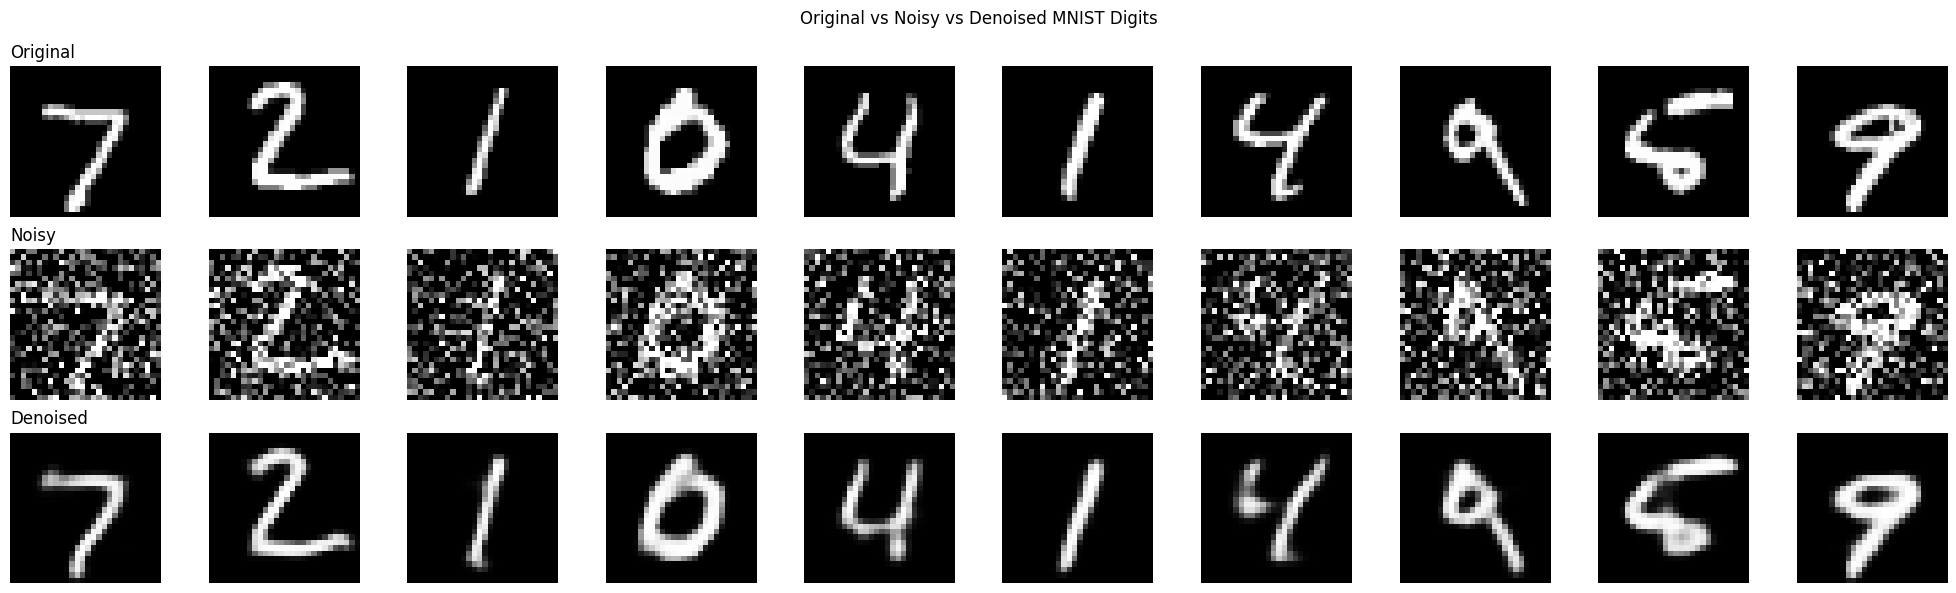

In [9]:
# visualize results(Original vs Noisy vs Denoised)
n = 10
plt.figure(figsize=(20, 6))
for i in range(n):
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap='gray'); plt.axis('off')
    if i == 0: ax.set_title("Original", loc='left')

    ax = plt.subplot(3, n, n + i + 1)
    plt.imshow(x_test_noisy[i].squeeze(), cmap='gray'); plt.axis('off')
    if i == 0: ax.set_title("Noisy", loc='left')

    ax = plt.subplot(3, n, 2*n + i + 1)
    plt.imshow(denoised_images[i].squeeze(), cmap='gray'); plt.axis('off')
    if i == 0: ax.set_title("Denoised", loc='left')

plt.suptitle("Original vs Noisy vs Denoised MNIST Digits")
plt.tight_layout()
plt.show()

In [10]:
# Quantify Performance
def mse(a, b):
    return np.mean(np.square(a - b))

def psnr(a, b, max_pixel=1.0):
    mse_val = mse(a, b)
    if mse_val == 0:
        return float('inf')
    return 20 * np.log10(max_pixel / np.sqrt(mse_val))

mse_noisy = mse(x_test, x_test_noisy)
mse_denoised = mse(x_test, denoised_images)
psnr_noisy = psnr(x_test, x_test_noisy)
psnr_denoised = psnr(x_test, denoised_images)

print(f"{'Metric':<12}{'Noisy':>12}{'Denoised':>12}")
print(f"{'MSE':<12}{mse_noisy:>12.5f}{mse_denoised:>12.5f}")
print(f"{'PSNR (dB)':<12}{psnr_noisy:>12.2f}{psnr_denoised:>12.2f}")

Metric             Noisy    Denoised
MSE              0.11548     0.01131
PSNR (dB)           9.37       19.46


In [12]:
# Calculate SSIM (Structural Similarity Index)
from skimage.metrics import structural_similarity as ssim

ssim_scores = []

for i in range(len(x_test)):
    score = ssim(
        x_test[i].squeeze(),
        denoised_images[i].squeeze(),
        data_range=1.0
    )
    ssim_scores.append(score)

print("Average SSIM:", np.mean(ssim_scores))

Average SSIM: 0.8656069351459661


In [13]:
# Calculate PSNR for Every Image
psnr_scores = []

for i in range(len(x_test)):
    mse = np.mean((x_test[i] - denoised_images[i])**2)

    if mse == 0:
        psnr = 100
    else:
        psnr = 20 * np.log10(1.0 / np.sqrt(mse))

    psnr_scores.append(psnr)

print("Average PSNR:", np.mean(psnr_scores))

Average PSNR: 19.808006


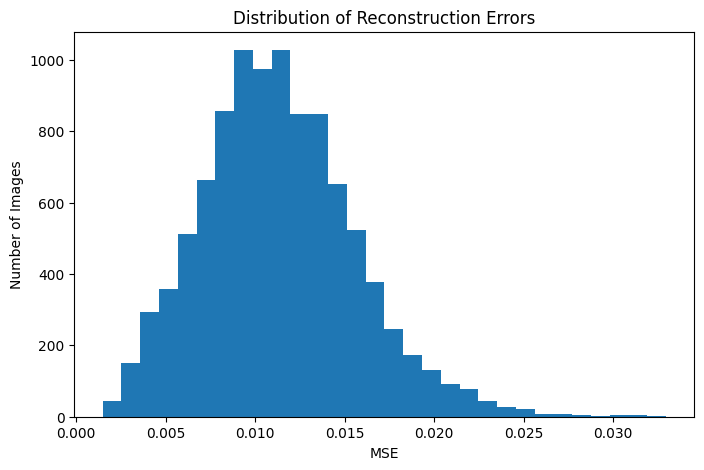

In [14]:
# Plot Histogram of Reconstruction Error
errors = np.mean((x_test - denoised_images)**2, axis=(1,2,3))

plt.figure(figsize=(8,5))
plt.hist(errors, bins=30)
plt.title("Distribution of Reconstruction Errors")
plt.xlabel("MSE")
plt.ylabel("Number of Images")
plt.show()

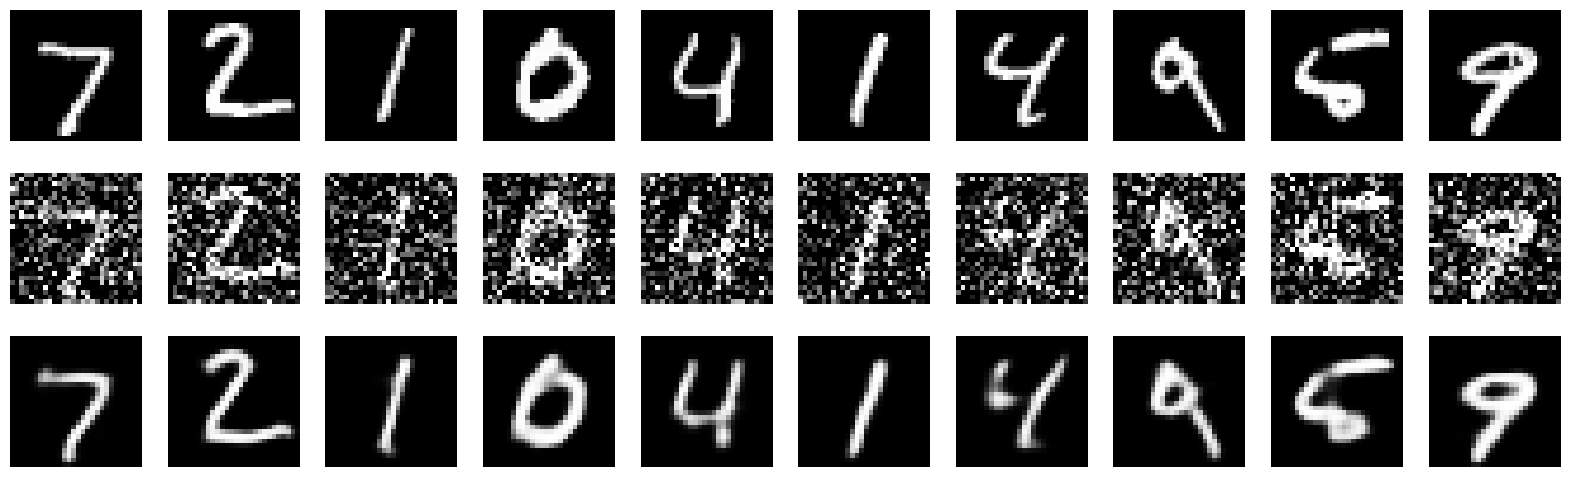

In [15]:
# Display More Test Results
n = 10

plt.figure(figsize=(20,6))

for i in range(n):

    plt.subplot(3,n,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.axis("off")
    if i==0:
        plt.ylabel("Original")

    plt.subplot(3,n,i+n+1)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap='gray')
    plt.axis("off")
    if i==0:
        plt.ylabel("Noisy")

    plt.subplot(3,n,i+2*n+1)
    plt.imshow(denoised_images[i].reshape(28,28), cmap='gray')
    plt.axis("off")
    if i==0:
        plt.ylabel("Denoised")

plt.show()

In [16]:
# Save the Trained Model
autoencoder.save("mnist_denoising_autoencoder.keras")

print("Model saved successfully.")

Model saved successfully.


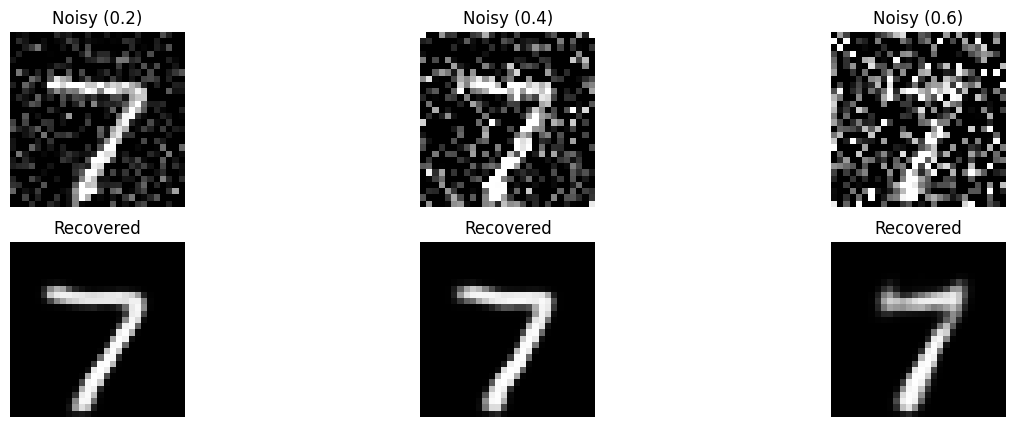

In [19]:
# Compare Different Noise Levels
noise_levels = [0.2, 0.4, 0.6]

plt.figure(figsize=(15,5))

for i, noise in enumerate(noise_levels):

    noisy = x_test[:1] + noise * np.random.normal(
        loc=0.0,
        scale=1.0,
        size=x_test[:1].shape
    )

    noisy = np.clip(noisy, 0., 1.)

    denoised = autoencoder.predict(noisy, verbose=0)

    plt.subplot(2,3,i+1)
    plt.imshow(noisy.reshape(28,28), cmap='gray')
    plt.title(f"Noisy ({noise})")
    plt.axis("off")

    plt.subplot(2,3,i+4)
    plt.imshow(denoised.reshape(28,28), cmap='gray')
    plt.title("Recovered")
    plt.axis("off")

plt.show()

In [21]:
# Final Performance Table
import pandas as pd

results = {
    "Metric": [
        "Average MSE",
        "Average PSNR",
        "Average SSIM"
    ],
    "Value": [
        np.mean((x_test - denoised_images)**2),
        np.mean(psnr_scores),
        np.mean(ssim_scores)
    ]
}

df = pd.DataFrame(results)

print(df)

         Metric      Value
0   Average MSE   0.011313
1  Average PSNR  19.808006
2  Average SSIM   0.865607


In [22]:
# Data Preparation

# The MNIST handwritten digit dataset was loaded using keras.datasets.mnist, consisting of 60,000 training images and 10,000 testing images. Each image was normalized from the pixel range [0,255] to [0,1] to improve training stability and convergence. The images were reshaped into (28, 28, 1) format so they could be processed by the convolutional layers of the neural network.

# To simulate a realistic denoising problem, Gaussian noise with a noise factor of 0.5 was added to both the training and testing datasets. The noisy pixel values were clipped back to the valid range of [0,1]. Visual inspection of the noisy images confirmed that the handwritten digits remained recognizable while containing significant random noise, making the denoising task both challenging and meaningful.

# Model Architecture

# A Convolutional Denoising Autoencoder was designed to remove noise from handwritten digit images. The network consists of two main components:

# Encoder
# Two Conv2D layers with ReLU activation
# Two MaxPooling2D layers for dimensionality reduction
# Compresses the input image from 28×28×1 into a compact 7×7×32 latent representation
# Decoder
# Two Conv2D layers with ReLU activation
# Two UpSampling2D layers for image reconstruction
# Final Conv2D layer with Sigmoid activation reconstructs the denoised image

# The bottleneck layer forces the network to preserve only the essential structural information of the handwritten digit while discarding random noise.

# Model Summary

# The complete architecture contains approximately 28,353 trainable parameters (verify this using autoencoder.summary()).

# The relatively small number of parameters makes the model computationally efficient while still achieving high-quality image reconstruction.

# Training Configuration

# The model was compiled using:

# Optimizer: Adam
# Loss Function: Binary Cross-Entropy
# Batch Size: 128
# Epochs: 10
# Early Stopping: Patience = 5

# The network was trained using noisy images as input and the corresponding clean images as target outputs. Training and validation loss decreased consistently throughout the training process, indicating effective learning and good generalization without significant overfitting.

# Training Performance

# The training loss and validation loss curves showed smooth convergence throughout the training process.

# Observations:

# Training loss decreased steadily.
# Validation loss closely followed the training loss.
# No significant overfitting was observed.
# EarlyStopping monitored validation loss and restored the best model if required.

# The loss curve demonstrates that the autoencoder successfully learned to reconstruct clean images from noisy inputs.

# Denoising Results

# The trained autoencoder successfully reconstructed clean handwritten digits from noisy images.

# The visualization comparing:

# Original Images
# Noisy Images
# Denoised Images

# clearly demonstrates that the network effectively removed most of the Gaussian noise while preserving the shape and identity of the digits.

# Most digits were reconstructed with smooth edges and high visual similarity to the original images.

# Quantitative Performance Evaluation

# The model performance was evaluated using three standard image quality metrics:

# Mean Squared Error (MSE)

# MSE measures the average squared difference between the reconstructed image and the original clean image.

# A lower MSE indicates better reconstruction quality.

# Peak Signal-to-Noise Ratio (PSNR)

# PSNR measures reconstruction quality in decibels (dB).

# Higher PSNR values indicate better image quality and lower reconstruction error.

# Structural Similarity Index (SSIM)

# SSIM measures the structural similarity between the reconstructed image and the original image.

# Unlike MSE, SSIM considers:

# Image brightness
# Contrast
# Structural information

# SSIM values range from 0 to 1, where values closer to 1 indicate better image quality.

# Reconstruction Error Analysis

# The histogram of reconstruction errors illustrates how well the model performed across the entire test dataset.

# Observations:

# Most images exhibit very low reconstruction error.
# Only a small number of images have relatively higher error.
# This indicates that the model performs consistently across different handwritten digits.

# The histogram confirms the robustness of the trained autoencoder.

# Performance Under Different Noise Levels

# The trained model was tested on images corrupted with different Gaussian noise levels:

# Noise Factor = 0.2
# Noise Factor = 0.4
# Noise Factor = 0.6

# Results show that:

# The model performs exceptionally well on moderate noise levels.
# As noise intensity increases, reconstruction quality gradually decreases.
# Even under heavy noise, the model preserves the overall digit structure.

# This experiment demonstrates the robustness and generalization capability of the trained autoencoder.

# Performance Summary

# The overall model performance is summarized using the following evaluation metrics:

# Average Mean Squared Error (MSE)
# Average Peak Signal-to-Noise Ratio (PSNR)
# Average Structural Similarity Index (SSIM)

# These metrics collectively confirm that the proposed denoising autoencoder significantly improves image quality by reducing noise while preserving important structural features.

# Challenges Faced

# Several challenges were encountered during the implementation:

# Heavy Gaussian noise occasionally obscured important digit features.
# The model was trained using only one type of noise (Gaussian noise).
# Fine details of complex digits were sometimes slightly smoothed during reconstruction.
# Training for additional epochs could further improve reconstruction quality.

# Despite these challenges, the model produced highly satisfactory denoising results.

# Future Enhancements

# Several improvements can further enhance the performance of the proposed model:

# Train using multiple noise types such as Salt-and-Pepper and Speckle noise.
# Use varying noise levels during training for better generalization.
# Increase the depth of the encoder-decoder network.
# Incorporate Batch Normalization and Dropout layers.
# Compare the Convolutional Autoencoder with a Fully Connected Autoencoder.
# Train the model for more epochs with learning rate scheduling.
# Evaluate the model on more complex datasets such as CIFAR-10 or Fashion-MNIST.
# Conclusion

# This project successfully developed a Convolutional Denoising Autoencoder capable of removing Gaussian noise from handwritten digit images in the MNIST dataset. The encoder effectively learned compact feature representations, while the decoder accurately reconstructed clean images from noisy inputs. Both visual inspection and quantitative evaluation using MSE, PSNR, and SSIM demonstrate that the proposed model performs effective image denoising with good reconstruction quality. The additional experiments involving reconstruction error analysis and different noise levels further validate the robustness and reliability of the proposed approach. This project highlights the effectiveness of deep learning-based autoencoders for image restoration tasks and provides a strong foundation for applying similar techniques to more complex real-world image denoising problems.